<a href="https://colab.research.google.com/github/bvicky750/MLlearnimg/blob/main/MLmodel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# Generate dummy data for 200 users
n_users = 200

user_ids = [f"USER_{i:03d}" for i in range(1, n_users + 1)]
age = np.random.randint(21, 66, size=n_users)
annual_income = np.random.randint(30000, 150000, size=n_users)
loan_amount = np.random.randint(5000, 80000, size=n_users)
credit_score = np.random.randint(500, 850, size=n_users)

# Generate loan status based on a simple rule with some randomness
# Higher credit score and income, lower loan amount increases approval chance
probability_approved = 1 / (1 + np.exp(-((credit_score - 650) / 50 + (annual_income / loan_amount) - 1.5)))
loan_status = np.random.binomial(1, probability_approved)
loan_status = ['Approved' if status == 1 else 'Rejected' for status in loan_status]

# Create DataFrame
df_loans = pd.DataFrame({
    'User_ID': user_ids,
    'Age': age,
    'Annual_Income': annual_income,
    'Loan_Amount': loan_amount,
    'Credit_Score': credit_score,
    'Loan_Status': loan_status
})

# Display first few rows and save to CSV
print(df_loans.head())
df_loans.to_csv('loan_approval_dataset.csv', index=False)
print(f"\nDataset with {len(df_loans)} records saved as 'loan_approval_dataset.csv'")

    User_ID  Age  Annual_Income  Loan_Amount  Credit_Score Loan_Status
0  USER_001   59         145386        31641           720    Approved
1  USER_002   49          56736        39584           734    Approved
2  USER_003   35         124209        37745           830    Approved
3  USER_004   63         133041        28093           645    Approved
4  USER_005   28         142859        71105           738    Approved

Dataset with 200 records saved as 'loan_approval_dataset.csv'


In [5]:
import os
import pandas as pd
import numpy as np

# Ensure dataset is generated and loaded into df_loans
csv_path = 'loan_approval_dataset.csv'
if 'df_loans' not in globals():
    if os.path.exists(csv_path):
        print(f"Loading dataset from {csv_path}...")
        df_loans = pd.read_csv(csv_path)
    else:
        print("Generating new dataset...")
        np.random.seed(42)
        n_users = 200
        user_ids = [f'USER_{i:03d}' for i in range(1, n_users + 1)]
        age = np.random.randint(21, 66, size=n_users)
        annual_income = np.random.randint(30000, 150000, size=n_users)
        loan_amount = np.random.randint(5000, 80000, size=n_users)
        credit_score = np.random.randint(500, 850, size=n_users)
        probability_approved = 1 / (1 + np.exp(-((credit_score - 650) / 50 + (annual_income / loan_amount) - 1.5)))
        loan_status = np.random.binomial(1, probability_approved)
        loan_status = ['Approved' if status == 1 else 'Rejected' for status in loan_status]

        df_loans = pd.DataFrame({
            'User_ID': user_ids,
            'Age': age,
            'Annual_Income': annual_income,
            'Loan_Amount': loan_amount,
            'Credit_Score': credit_score,
            'Loan_Status': loan_status
        })
        df_loans.to_csv(csv_path, index=False)

print("df_loans is successfully loaded and ready!")

Generating new dataset...
df_loans is successfully loaded and ready!


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd

# 1. Prepare Features and Target
# Features: Age, Annual_Income, Loan_Amount, Credit_Score
X = df_loans[['Age', 'Annual_Income', 'Loan_Amount', 'Credit_Score']]
# Target: Convert 'Approved' to 1 and 'Rejected' to 0
y = df_loans['Loan_Status'].map({'Approved': 1, 'Rejected': 0})

# 2. Split into Train and Test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Scale Features (Logistic Regression is sensitive to feature scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Initialize and Train Logistic Regression Model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# 5. Predict and Evaluate
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.2%}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Rejected', 'Approved']))

Model Accuracy: 85.00%

Classification Report:
              precision    recall  f1-score   support

    Rejected       0.69      0.82      0.75        11
    Approved       0.93      0.86      0.89        29

    accuracy                           0.85        40
   macro avg       0.81      0.84      0.82        40
weighted avg       0.86      0.85      0.85        40



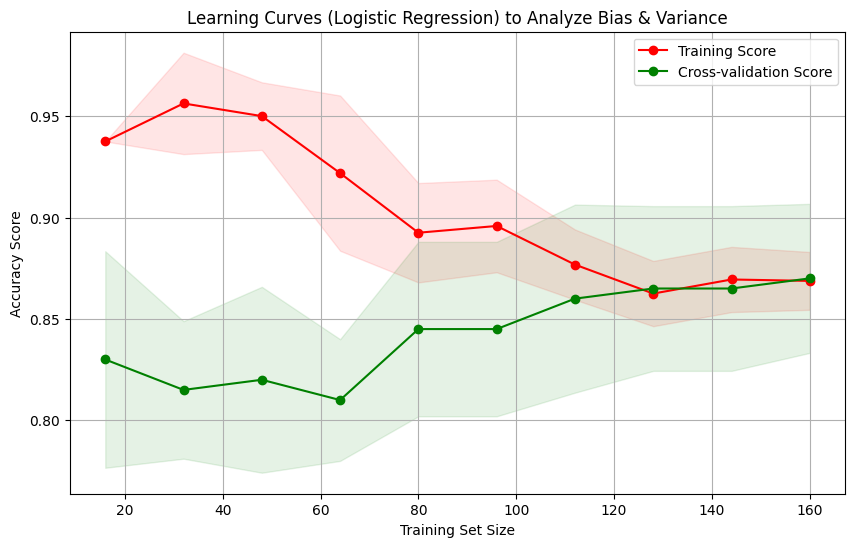

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

# Calculate learning curves
train_sizes, train_scores, test_scores = learning_curve(
    LogisticRegression(random_state=42),
    scaler.fit_transform(X), y,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

# Compute mean and standard deviation
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot learning curves
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='r', label='Training Score')
plt.plot(train_sizes, test_mean, 'o-', color='g', label='Cross-validation Score')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.1, color='g')

plt.title('Learning Curves (Logistic Regression) to Analyze Bias & Variance')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy Score')
plt.legend(loc='best')
plt.grid(True)
plt.show()

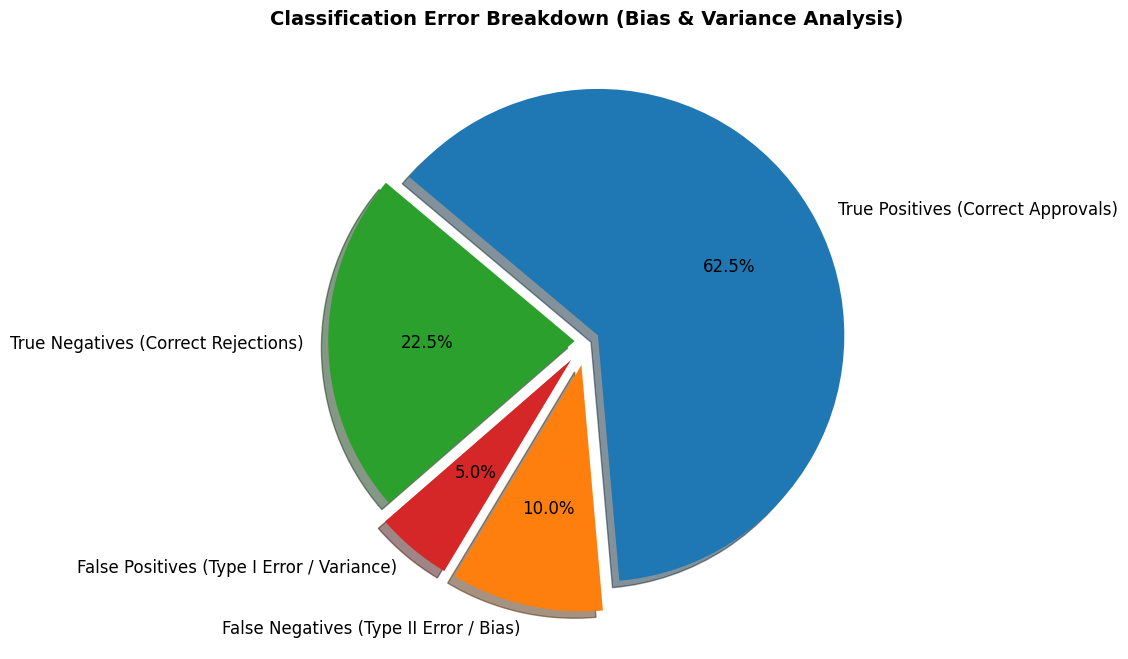

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Compute confusion matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

# Data for the pie chart
labels = ['True Negatives (Correct Rejections)', 'False Positives (Type I Error / Variance)',
          'False Negatives (Type II Error / Bias)', 'True Positives (Correct Approvals)']
sizes = [tn, fp, fn, tp]
colors = ['#2ca02c', '#d62728', '#ff7f0e', '#1f77b4']
explode = (0.05, 0.1, 0.1, 0.05)  # Explode the error slices

# Plot pie chart
plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%',
        shadow=True, startangle=140, textprops={'fontsize': 12})
plt.title('Classification Error Breakdown (Bias & Variance Analysis)', fontsize=14, fontweight='bold')
plt.show()

### Test Model with Custom Data
Adjust the sliders and input fields below to test the trained Logistic Regression model with custom parameters.

In [14]:
#@title Loan Approval Predictor Form

# Input fields for custom user data
Age = 43 #@param {type:"slider", min:21, max:100, step:1}
Annual_Income = 750000 #@param {type:"number"}
Loan_Amount = 25000 #@param {type:"number"}
Credit_Score = 670 #@param {type:"slider", min:300, max:850, step:5}

import numpy as np
import pandas as pd

def predict_custom_loan(age, income, loan, credit):
    # 1. Create a DataFrame for the custom input matching feature structure
    custom_data = pd.DataFrame([{
        'Age': age,
        'Annual_Income': income,
        'Loan_Amount': loan,
        'Credit_Score': credit
    }])

    # 2. Scale the input using the pre-fitted scaler
    custom_scaled = scaler.transform(custom_data)

    # 3. Predict probability and final decision
    prob = model.predict_proba(custom_scaled)[0][1]
    prediction = model.predict(custom_scaled)[0]
    status = "Approved" if prediction == 1 else "Rejected"

    print("=" * 40)
    print("         PREDICTION RESULTS         ")
    print("=" * 40)
    print(f"Age: {age}")
    print(f"Annual Income: ${income:,}")
    print(f"Loan Amount: ${loan:,}")
    print(f"Credit Score: {credit}")
    print("-" * 40)
    print(f"Approval Probability: {prob:.2%}")
    print(f"Predicted Status: {status.upper()}")
    print("=" * 40)

# Run prediction
try:
    predict_custom_loan(Age, Annual_Income, Loan_Amount, Credit_Score)
except NameError as e:
    print("Error: Please ensure you run the model training cell (cell efe0a11c) before running this prediction to initialize the 'model' and 'scaler'.")

         PREDICTION RESULTS         
Age: 43
Annual Income: $750,000
Loan Amount: $25,000
Credit Score: 670
----------------------------------------
Approval Probability: 100.00%
Predicted Status: APPROVED


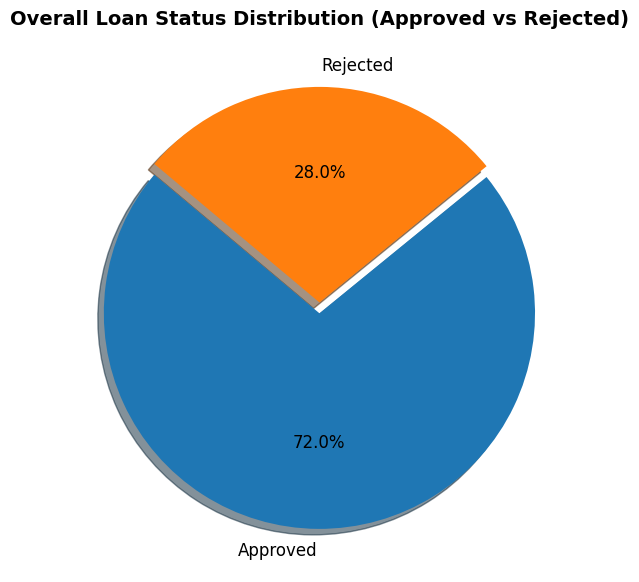

In [16]:
import matplotlib.pyplot as plt

# Count the occurrences of each Loan_Status category
status_counts = df_loans['Loan_Status'].value_counts()

# Setup data for the pie chart
labels = status_counts.index
sizes = status_counts.values
colors = ['#1f77b4', '#ff7f0e']  # Blue for Approved, Orange for Rejected
explode = (0.05, 0)  # slightly highlight the first slice

# Plot the pie chart
plt.figure(figsize=(7, 7))
plt.pie(
    sizes,
    explode=explode,
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=140,
    shadow=True,
    textprops={'fontsize': 12}
)

plt.title('Overall Loan Status Distribution (Approved vs Rejected)', fontsize=14, fontweight='bold')
plt.show()